In [13]:
import os
import pandas as pd
import numpy as np
from pathlib import Path

from statsmodels.regression.linear_model import OLS

import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.gridspec import GridSpec

In [14]:
base_path = Path.cwd()

CASES_REPLACEMENT_FILE = "fitted_prediction_수정.xlsx"
SCENARIO_CASES_COLUMNS = {
    "SSP1-2.6": "SSP126",
    "SSP2-4.5": "SSP245",
    "SSP3-7.0": "SSP370",
    "SSP5-8.5": "SSP585",
}

In [15]:
SAVE_FIG = True
figure_dir = os.path.join(base_path, "Figure")

rcParams["font.family"] = "Arial"
rcParams["font.sans-serif"] = ["Arial"]
rcParams["axes.unicode_minus"] = False

plt.rcParams.update({
    "font.family": "Arial",
    "font.sans-serif": ["Arial"]
})

In [16]:
def read_excel_cached(path, *args, **kwargs):
    key = (os.fspath(path), repr(args), repr(sorted(kwargs.items())))

    if key not in _EXCEL_CACHE:
        _EXCEL_CACHE[key] = pd.read_excel(path, *args, **kwargs)

    cached = _EXCEL_CACHE[key]

    if isinstance(cached, dict):
        return {sheet: df.copy() for sheet, df in cached.items()}

    return cached.copy()


def get_cases_replacement_path(base_path):
    replacement_path = os.path.join(base_path, CASES_REPLACEMENT_FILE)

    if os.path.exists(replacement_path):
        return replacement_path

    raise FileNotFoundError(
        f"Cases replacement file not found: {replacement_path}"
    )


def replace_cases_2025_2069(temp_df, scenario, base_path, cases_col="Cases"):
    temp_df = temp_df.copy()

    if scenario not in SCENARIO_CASES_COLUMNS:
        raise ValueError(f"The scenario is not supported: {scenario}")

    year_col = "Year" if "Year" in temp_df.columns else "year" if "year" in temp_df.columns else None
    if year_col is None:
        raise ValueError("We need 'Year' or 'year' column in the forecasting SSP file.")

    if cases_col not in temp_df.columns:
        raise ValueError(f"forecasting SSP file requires '{cases_col}' column.")

    replacement_path = get_cases_replacement_path(base_path)
    replacement_df = read_excel_cached(replacement_path)

    scenario_col = SCENARIO_CASES_COLUMNS[scenario]
    required_cols = ["Year", scenario_col]
    missing_cols = [col for col in required_cols if col not in replacement_df.columns]
    if missing_cols:
        raise ValueError(
            "Cases replacement file is missing required columns: " + ", ".join(missing_cols)
        )

    replacement_df = replacement_df[required_cols].copy()
    replacement_df["Year"] = pd.to_numeric(replacement_df["Year"], errors="coerce").astype("Int64")
    replacement_df[scenario_col] = pd.to_numeric(replacement_df[scenario_col], errors="coerce")

    replacement_df = replacement_df[
        (replacement_df["Year"] >= 2025) &
        (replacement_df["Year"] <= 2069)
    ].copy()

    replacement_df = replacement_df.rename(columns={scenario_col: "Cases_replacement"})

    temp_df[year_col] = pd.to_numeric(temp_df[year_col], errors="coerce").astype("Int64")
    temp_df[cases_col] = pd.to_numeric(temp_df[cases_col], errors="coerce").astype(float)

    merged = temp_df.merge(replacement_df, left_on=year_col, right_on="Year", how="left")

    replace_mask = (
        (merged[year_col] >= 2025) &
        (merged[year_col] <= 2069) &
        (merged["Cases_replacement"].notna())
    )

    merged.loc[replace_mask, cases_col] = merged.loc[replace_mask, "Cases_replacement"]

    drop_cols = ["Cases_replacement"]

    if "Year_y" in merged.columns:
        drop_cols.append("Year_y")
    elif year_col != "Year" and "Year" in merged.columns:
        drop_cols.append("Year")

    merged = merged.drop(columns=[col for col in drop_cols if col in merged.columns])

    if "Year_x" in merged.columns:
        merged = merged.rename(columns={"Year_x": year_col})

    return merged

# **Data Check**

In [17]:
case_file = os.path.join(base_path, "fitted_prediction_수정.xlsx")

_EXCEL_CACHE = {}
case_df = read_excel_cached(case_file)

In [18]:
save_name = "Figure6.tiff"
save_path = os.path.join(figure_dir, save_name)


scenario_colors = {
    "SSP1-2.6": "#00ff33",
    "SSP2-4.5": "#1f77b4",
    "SSP3-7.0": "#ff9900",
    "SSP5-8.5": "#ff1f1f"
}

scenario_case_col_map = {
    "SSP1-2.6": "SSP126",
    "SSP2-4.5": "SSP245",
    "SSP3-7.0": "SSP370",
    "SSP5-8.5": "SSP585"
}


if "year" in case_df.columns:
    case_df = case_df.rename(columns={"year": "Year"})

if "population" in case_df.columns:
    case_df = case_df.rename(columns={"population": "Population_60"})

required_cols = ["Year", "Population_60"] + list(scenario_case_col_map.values())

missing_cols = [
    col for col in required_cols
    if col not in case_df.columns
]
if missing_cols:
    raise ValueError(f"Cases file is missing required columns: {missing_cols}")

df_list = []
for scenario, case_col in scenario_case_col_map.items():
    temp = case_df[["Year", "Population_60", case_col]].copy()
    temp = temp.rename(columns={case_col: "Cases"})
    temp = temp[(temp["Year"] >= 2025) & (temp["Year"] <= 2069)].copy()

    temp["Scenario"] = scenario
    temp["Population_60_million"] = temp["Population_60"] / 1_000_000

    temp = temp[["Year", "Population_60", "Cases", "Scenario", "Population_60_million"]].copy()
    df_list.append(temp)

all_df = pd.concat(df_list, ignore_index=True)

# **Regression analysis**

In [19]:
def run_fixed_alpha_regression_by_scenario(
    df,
    scenarios,
    x_col="Population_60_million",
    y_col="Cases"
):
    analysis_df = df[df["Scenario"].isin(scenarios)].copy()

    keep_cols = ["Scenario", x_col, y_col]
    if "Year" in analysis_df.columns:
        keep_cols = ["Year"] + keep_cols

    analysis_df = analysis_df[keep_cols].dropna()

    x_min = analysis_df[x_col].min()

    start_rows = (
        analysis_df
        .sort_values(["Scenario", x_col])
        .groupby("Scenario", as_index=False)
        .first()
    )

    alpha_fixed = start_rows[y_col].mean()

    print("\n" + "=" * 80)
    print(f"Fixed-alpha regression setting: {scenarios}")
    print("=" * 80)
    print(f"x_min ({x_col}) = {x_min}")
    print(f"alpha_fixed ({y_col} mean of scenario starting points) = {alpha_fixed}")
    print("Scenario starting points used for alpha_fixed")

    regression_rows = []

    for scenario in scenarios:
        temp = analysis_df[analysis_df["Scenario"] == scenario].copy()
        temp = temp[[x_col, y_col]].dropna()

        x = temp[x_col]
        y = temp[y_col]

        x_centered = x - x_min
        y_centered = y - alpha_fixed


        X = x_centered.to_frame(name="x_centered")

        model = OLS(y_centered, X).fit()

        beta = model.params["x_centered"]
        beta_t = model.tvalues["x_centered"]
        beta_p = model.pvalues["x_centered"]

        beta_ci_low, beta_ci_high = model.conf_int().loc["x_centered"]

        yhat = alpha_fixed + beta * x_centered
        sse = np.sum((y - yhat) ** 2)
        sst = np.sum((y - y.mean()) ** 2)
        r2_manual = 1 - (sse / sst)

        n_obs = len(temp)
        p = 1

        regression_rows.append({
            "Scenario": scenario,
            "N": n_obs,
            "x_min": x_min,

            "Alpha_fixed": alpha_fixed,
            "Alpha_95CI_Low": np.nan,
            "Alpha_95CI_High": np.nan,
            "Alpha_T_statistics": np.nan,
            "Alpha_p_value": np.nan,

            "Beta_Value": beta,
            "Beta_95CI_Low": beta_ci_low,
            "Beta_95CI_High": beta_ci_high,
            "Beta_T_statistics": beta_t,
            "Beta_p_value": beta_p,

            "R_squared": r2_manual,
            "AIC": model.aic,
            "BIC": model.bic
        })


    regression_table = pd.DataFrame(regression_rows)

    return regression_table, x_min, alpha_fixed

In [20]:
def get_fixed_alpha_regression_line(
    df,
    scenario,
    x_min,
    alpha_fixed,
    x_col="Population_60_million",
    y_col="Cases"
):
    temp = df[df["Scenario"] == scenario].copy()
    temp = temp[[x_col, y_col]].dropna()

    x = temp[x_col]
    y = temp[y_col]

    x_centered = x - x_min
    y_centered = y - alpha_fixed

    X = x_centered.to_frame(name="x_centered")

    model = OLS(y_centered, X).fit()

    beta = model.params["x_centered"]

    x_line = np.linspace(x_min, x.max(), 100)
    y_line = alpha_fixed + beta * (x_line - x_min)

    return x_line, y_line, model



def make_heatmap_data(df, scenarios, bin_edges=None, x_col="Population_60_million", y_col="Cases"):
    if bin_edges is None:
        bin_edges = [14, 17, 20, 23]

    bin_labels = [
        f"{bin_edges[i]}–{bin_edges[i + 1]}"
        for i in range(len(bin_edges) - 1)
    ]

    temp_df = df.copy()
    temp_df["Pop_bin"] = pd.cut(temp_df[x_col], bins=bin_edges, labels=bin_labels, include_lowest=True, right=False)
    heatmap_rows = []

    for scenario in scenarios:
        scenario_mean = (
            temp_df[temp_df["Scenario"] == scenario]
            .groupby("Pop_bin", observed=False)[y_col]
            .mean()
            .reindex(bin_labels)
        )
        heatmap_rows.append(scenario_mean.values)

    heatmap_data = np.array(heatmap_rows)

    return heatmap_data, bin_labels

In [21]:
def plot_regression_figure(
    df,
    scenarios,
    regression_table,
    x_min,
    alpha_fixed,
    save_fig=False,
    save_path=None,
    x_col="Population_60_million",
    y_col="Cases"
):
    heatmap_data, bin_labels = make_heatmap_data(
        df=df,
        scenarios=scenarios,
        bin_edges=[14, 17, 20, 23],
        x_col=x_col,
        y_col=y_col
    )

    fig = plt.figure(figsize=(11, 9))

    gs = GridSpec(
        2,
        2,
        height_ratios=[1.0, 1.05],
        width_ratios=[1.0, 1.15],
        hspace=0.45,
        wspace=0.45
    )

    axA = fig.add_subplot(gs[0, :])
    axB = fig.add_subplot(gs[1, 0])
    axC = fig.add_subplot(gs[1, 1])

    # ========================================================
    # A plot: population vs cases fixed-alpha regression
    # ========================================================
    for scenario in scenarios:
        temp = df[df["Scenario"] == scenario].copy()

        x = temp[x_col]
        y = temp[y_col]

        x_line, y_line, model = get_fixed_alpha_regression_line(
            df=df,
            scenario=scenario,
            x_min=x_min,
            alpha_fixed=alpha_fixed,
            x_col=x_col,
            y_col=y_col
        )

        axA.scatter(
            x,
            y,
            color=scenario_colors[scenario],
            edgecolor=scenario_colors[scenario],
            alpha=0.75,
            s=45,
            zorder=3
        )

        axA.plot(
            x_line,
            y_line,
            color=scenario_colors[scenario],
            linestyle="--",
            linewidth=2,
            label=scenario,
            zorder=4
        )

    axA.set_xlabel("Population (60+)", fontsize=20)
    axA.set_ylabel("Yearly number of cases (60+)", fontsize=18)

    axA.set_xlim(14, 23)
    axA.set_ylim(150, 350)

    axA.set_xticks([14, 15.5, 17, 18.5, 20, 21.5, 23])
    axA.set_yticks([150, 250, 350])

    axA.tick_params(
        axis="both",
        labelsize=18,
        length=7,
        width=2,
        color="black"
    )

    axA.legend(
        loc="upper left",
        fontsize=15,
        frameon=False,
        facecolor="white"
    )

    axA.text(
        0.92,
        1.05,
        "(×10⁶)",
        transform=axA.transAxes,
        fontsize=18,
        fontweight="bold",
        fontfamily="Arial"
    )

    axA.text(
        0.01,
        1.03,
        "A",
        transform=axA.transAxes,
        fontsize=26,
        fontweight="bold",
        fontfamily="Arial"
    )

    axA.grid(False)

    for spine in axA.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # ========================================================
    # B plot: beta coefficient forest plot
    # ========================================================
    slope_df = regression_table.copy()
    slope_df = slope_df[slope_df["Scenario"].isin(scenarios)].copy()

    slope_df["Scenario"] = pd.Categorical(
        slope_df["Scenario"],
        categories=scenarios,
        ordered=True
    )

    slope_df = slope_df.sort_values("Scenario").reset_index(drop=True)

    y_pos = np.arange(len(slope_df))[::-1]

    for i, row in slope_df.iterrows():
        scenario = row["Scenario"]
        color = scenario_colors[scenario]
        y = y_pos[i]

        axB.errorbar(
            row["Beta_Value"],
            y,
            xerr=[
                [row["Beta_Value"] - row["Beta_95CI_Low"]],
                [row["Beta_95CI_High"] - row["Beta_Value"]]
            ],
            fmt="o",
            color=color,
            ecolor=color,
            elinewidth=2.3,
            capsize=5,
            markersize=9,
            zorder=3
        )

        axB.text(
            row["Beta_Value"],
            y - 0.18,
            f"{row['Beta_Value']:.2f}",
            ha="center",
            va="top",
            fontsize=14,
            color=color,
            fontweight="bold",
            fontfamily="Arial"
        )

        axB.text(
            row["Beta_Value"],
            y - 0.42,
            f"({row['Beta_95CI_Low']:.2f}–{row['Beta_95CI_High']:.2f})",
            ha="center",
            va="top",
            fontsize=13,
            color=color,
            fontweight="bold",
            fontfamily="Arial"
        )

    axB.set_yticks(y_pos)

    axB.set_yticklabels(
        slope_df["Scenario"],
        fontsize=14,
        fontfamily="Arial"
    )

    axB.set_xlabel(
        "Annual SFTS cases per one million adults aged 60+",
        fontsize=13,
        fontfamily="Arial"
    )

    axB.set_xlim(
        slope_df["Beta_95CI_Low"].min() - 1,
        slope_df["Beta_95CI_High"].max() + 1.5
    )

    axB.set_ylim(
        y_pos.min() - 0.85,
        y_pos.max() + 0.45
    )

    axB.tick_params(
        axis="x",
        labelsize=16,
        length=5,
        width=1.5,
        color="black"
    )

    axB.tick_params(
        axis="y",
        labelsize=14,
        length=5,
        width=1.5,
        color="black"
    )

    axB.text(
        0.0,
        1.1,
        "B",
        transform=axB.transAxes,
        fontsize=26,
        fontweight="bold",
        fontfamily="Arial"
    )

    axB.grid(False)

    for spine in axB.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    # ========================================================
    # C plot: population bin - cases heatmap
    # ========================================================
    im = axC.imshow(
        heatmap_data,
        cmap="YlOrRd",
        aspect="auto",
        vmin=np.nanmin(heatmap_data),
        vmax=np.nanmax(heatmap_data)
    )

    axC.set_xticks(np.arange(len(bin_labels)))

    axC.set_xticklabels(
        bin_labels,
        fontsize=14,
        fontfamily="Arial"
    )

    axC.set_yticks(np.arange(len(scenarios)))

    axC.set_yticklabels(
        scenarios,
        fontsize=15,
        fontfamily="Arial"
    )

    axC.set_xlabel(
        "Population aged 60+ (million)",
        fontsize=14,
        fontfamily="Arial"
    )

    axC.tick_params(
        axis="x",
        labelsize=14,
        length=5,
        width=1.5,
        color="black"
    )

    axC.tick_params(
        axis="y",
        labelsize=15,
        length=5,
        width=1.5,
        color="black"
    )

    for i in range(heatmap_data.shape[0]):
        for j in range(heatmap_data.shape[1]):
            value = heatmap_data[i, j]

            if not np.isnan(value):
                axC.text(
                    j,
                    i,
                    f"{value:.0f}",
                    ha="center",
                    va="center",
                    fontsize=14,
                    fontweight="bold",
                    fontfamily="Arial",
                    color="black"
                )

    axC.set_xticks(
        np.arange(-0.5, len(bin_labels), 1),
        minor=True
    )

    axC.set_yticks(
        np.arange(-0.5, len(scenarios), 1),
        minor=True
    )

    axC.grid(
        which="minor",
        color="white",
        linestyle="-",
        linewidth=1.2
    )

    axC.tick_params(
        which="minor",
        bottom=False,
        left=False
    )

    cbar = fig.colorbar(
        im,
        ax=axC,
        fraction=0.046,
        pad=0.05
    )

    cbar.set_label(
        "Mean annual SFTS cases",
        fontsize=12,
        fontfamily="Arial"
    )

    cbar.ax.tick_params(
        labelsize=13,
        length=5,
        width=1.2,
        color="black"
    )

    for tick in cbar.ax.get_yticklabels():
        tick.set_fontfamily("Arial")

    cbar.outline.set_edgecolor("black")
    cbar.outline.set_linewidth(1.2)

    axC.text(
        0.0,
        1.1,
        "C",
        transform=axC.transAxes,
        fontsize=26,
        fontweight="bold",
        fontfamily="Arial"
    )

    for spine in axC.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    plt.tight_layout()

    if save_fig:
        if save_path is None:
            raise ValueError("IF 'save_fig=True', then 'save_path' must be specified.")

        save_dir = os.path.dirname(save_path)

        if os.path.isfile(save_dir):
            raise ValueError(
                f"The save folder path exists as a file: {save_dir}"
            )

        os.makedirs(save_dir, exist_ok=True)

        fig.savefig(
            save_path,
            dpi=300,
            format="tiff",
            bbox_inches="tight"
        )

        print(f"Saved: {save_path}")

    plt.show()



def make_print_tables(regression_table):
    regression_print = regression_table.copy()

    round_cols_reg = [
        "x_min",
        "Alpha_fixed",
        "Alpha_95CI_Low",
        "Alpha_95CI_High",
        "Alpha_T_statistics",
        "Alpha_p_value",
        "Beta_Value",
        "Beta_95CI_Low",
        "Beta_95CI_High",
        "Beta_T_statistics",
        "Beta_p_value",
        "R_squared",
        "AIC",
        "BIC"
    ]

    for col in round_cols_reg:
        if col in regression_print.columns:
            regression_print[col] = regression_print[col].round(6)


    return regression_print

In [22]:
def format_p_value(p):
    if pd.isna(p):
        return "Fixed"
    if p < 0.001:
        return "< 0.001*"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"


def format_ci(low, high, digits=2):
    if pd.isna(low) or pd.isna(high):
        return "Fixed"
    return f"({low:.{digits}f}–{high:.{digits}f})"


def make_paper_style_table(regression_table):
    table = regression_table.copy()

    table["α Value"] = table["Alpha_fixed"].map(lambda x: f"{x:.2f}")
    table["α 95% CI"] = "Fixed"
    table["α T-statistics"] = "Fixed"
    table["α p-value"] = "Fixed"

    table["β Value"] = table["Beta_Value"].map(lambda x: f"{x:.2f}")
    table["β 95% CI"] = table.apply(lambda row: format_ci(row["Beta_95CI_Low"], row["Beta_95CI_High"], digits=2), axis=1)
    table["β T-statistics"] = table["Beta_T_statistics"].map(lambda x: f"{x:.2f}")
    table["β p-value"] = table["Beta_p_value"].map(format_p_value)
    table["R²"] = table["R_squared"].map(lambda x: f"{x:.2f}")

    paper_regression = table[["Scenario", "N", "x_min",
            "α Value", "α 95% CI", "α T-statistics", "α p-value",
            "β Value", "β 95% CI", "β T-statistics", "β p-value",
            "R²"]].copy()

    return paper_regression

In [23]:
scenarios_4 = ["SSP1-2.6", "SSP2-4.5", "SSP3-7.0", "SSP5-8.5"]
scenarios_2 = ["SSP1-2.6", "SSP5-8.5"]

regression_4, x_min_4, alpha_fixed_4 = run_fixed_alpha_regression_by_scenario(
    df=all_df,
    scenarios=scenarios_4,
    x_col="Population_60_million",
    y_col="Cases"
)
regression_4_print = make_print_tables(regression_4)
paper_regression_4 = make_paper_style_table(regression_4)


print("\n" + "=" * 80)
print("4-scenario paper-style regression table")
print("=" * 80)
display(paper_regression_4)



Fixed-alpha regression setting: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
x_min (Population_60_million) = 14.669373
alpha_fixed (Cases mean of scenario starting points) = 157.12228696106726
Scenario starting points used for alpha_fixed

4-scenario paper-style regression table


,Scenario,N,x_min,α Value,α 95% CI,α T-statistics,α p-value,β Value,β 95% CI,β T-statistics,β p-value,R²
0,SSP1-2.6,45,14.669373,157.12,Fixed,Fixed,Fixed,9.29,(8.47–10.11),22.81,< 0.001*,0.61
1,SSP2-4.5,45,14.669373,157.12,Fixed,Fixed,Fixed,10.45,(9.49–11.41),21.85,< 0.001*,0.49
2,SSP3-7.0,45,14.669373,157.12,Fixed,Fixed,Fixed,12.50,(11.59–13.40),27.78,< 0.001*,0.71
3,SSP5-8.5,45,14.669373,157.12,Fixed,Fixed,Fixed,13.25,(12.10–14.41),23.16,< 0.001*,0.61


C:\Users\admin\AppData\Local\Temp\ipykernel_50960\1098042893.py:372: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: c:\Users\admin\Dropbox\(연구) MSOL\2025_SFTS\CNN_LSTM\YI\Figure\Figure6.tiff


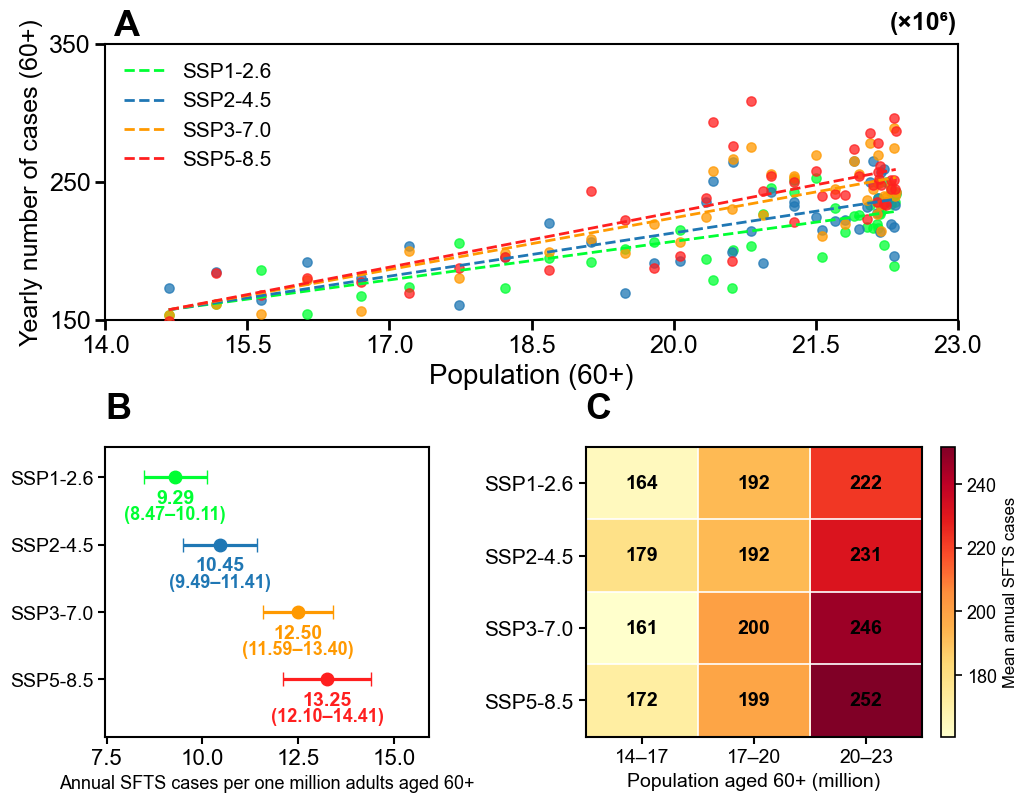

In [25]:
plot_regression_figure(
    df=all_df,
    scenarios=scenarios_4,
    regression_table=regression_4,
    x_min=x_min_4,
    alpha_fixed=alpha_fixed_4,
    save_fig=True,
    save_path=save_path,
    x_col="Population_60_million",
    y_col="Cases"
)